# Superpixel Graph Visualization

This notebook helps inspect the cached superpixel graph pipeline for one mammogram image.

Given one `IMAGE_ID` and one split (`train`, `val`, or `test`), it will:

- load the PNG image and frozen ResNet feature map,
- reconstruct the superpixel segmentation using the same helper functions as the cache builder,
- show raw SLIC superpixels, filtered superpixels, and final node candidates,
- show what survives similarity thresholding,
- visualize the final graph overlay and adjacency matrix,
- display node-feature sizes and simple feature diagnostics.

Important note: in the current implementation, **similarity thresholding filters edges, not nodes**. The notebook therefore reports both:

- how many node candidates exist before edge building,
- how many nodes have at least one threshold-passing neighbor before fallback,
- and the final graph after fallback neighbors are added.


In [8]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from PIL import Image

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks_visualization':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing.build_superpixel_graph_cache import (
    _build_breast_mask,
    _build_feature_grid_pooling,
    _build_similarity_adjacency,
    _compute_node_stats,
    _compute_superpixels,
    _filter_and_reindex_labels,
)

plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['image.cmap'] = 'gray'
torch.set_grad_enabled(False)


torch.autograd.grad_mode.set_grad_enabled(mode=False)

## Configuration

Set the split and image you want to inspect.

`IMAGE_ID` can be either:

- a full PNG filename such as `10093833_R_MLO_2013-06-21_7135_neg_nocancer.png`, or
- a patient ID such as `10093833`.

If you pass only a patient ID and there are multiple matching images in the split, the notebook uses `MATCH_INDEX` to choose which one to open from the sorted match list.


In [9]:
DATA_ROOT = PROJECT_ROOT.parent / 'EMBED_Split_Cropped_PNG_Uniform_Orientation'
FEATURE_CACHE_ROOT = PROJECT_ROOT / 'output_feature_cache' / 'resnet18_no_alignment_uniform_orientation_cropped_early_stop'
CACHE_ROOT = PROJECT_ROOT / 'output_graph_cache' / 'superpixel_uniform_orientation'

SPLIT = 'test'
IMAGE_ID = '10093833'
MATCH_INDEX = 0

NUM_SUPERPIXELS = 64
COMPACTNESS = 10.0
SIGMA = 1.0
MIN_SUPERPIXEL_AREA = 64
SIMILARITY_THRESHOLD = 0.70
K_MIN = 2
K_MAX = 16

SELECT_NODE_ID = 0
MAX_DRAWN_EDGES = 250

assert SPLIT in {'train', 'val', 'test'}


## Helpers

The helper functions below intentionally mirror the cache-building logic so the notebook reconstructs the same superpixel pipeline used by `src/preprocessing/build_superpixel_graph_cache.py`.


In [10]:
def resolve_image_id(data_root: Path, split: str, image_id: str | None, match_index: int = 0) -> str:
    split_dir = data_root / split
    filenames = sorted(name for name in os.listdir(split_dir) if name.lower().endswith('.png'))
    if not filenames:
        raise FileNotFoundError(f'No PNG files found in {split_dir}')

    if image_id is None:
        selected = filenames[0]
        print(f'IMAGE_ID is None, using first image in {split}: {selected}')
        return selected

    if image_id in filenames:
        print(f'Using exact image filename: {image_id}')
        return image_id

    patient_matches = [name for name in filenames if name.startswith(f'{image_id}_')]
    if patient_matches:
        if match_index < 0 or match_index >= len(patient_matches):
            raise IndexError(
                f'match_index={match_index} is out of range for patient {image_id}. '
                f'Found {len(patient_matches)} matches.'
            )
        selected = patient_matches[match_index]
        print(f'IMAGE_ID={image_id} matched {len(patient_matches)} files in {split}. Using index {match_index}: {selected}')
        return selected

    raise FileNotFoundError(
        f'Could not resolve IMAGE_ID={image_id!r} in split={split}. '
        'Pass a full PNG filename or a patient ID prefix.'
    )


def image_path_for(data_root: Path, split: str, image_id: str) -> Path:
    return data_root / split / image_id


def feature_cache_path_for(feature_cache_root: Path, split: str, image_id: str) -> Path:
    return feature_cache_root / split / f'{Path(image_id).stem}.resnet18_feature.pt'


def graph_cache_path_for(cache_root: Path, split: str, image_id: str) -> Path:
    return cache_root / split / f'{Path(image_id).stem}.superpixel_graph.pt'


def load_image(image_path: Path) -> np.ndarray:
    image = np.array(Image.open(image_path)).astype(np.float32)
    if image.ndim != 2:
        raise ValueError(f'Expected grayscale image, got shape {image.shape}')
    return image


def load_feature_map(feature_cache_root: Path, split: str, image_id: str) -> torch.Tensor:
    payload = torch.load(feature_cache_path_for(feature_cache_root, split, image_id), map_location='cpu')
    feature_map = payload['feature_map'] if isinstance(payload, dict) else payload
    return feature_map.to(dtype=torch.float32)


def load_cached_metadata(cache_root: Path, split: str, image_id: str):
    path = graph_cache_path_for(cache_root, split, image_id)
    if not path.exists():
        return None
    return torch.load(path, map_location='cpu')


def to_masked_labels(label_map: np.ndarray):
    return np.ma.masked_where(label_map < 0, label_map)


def normalized_similarity(node_features: torch.Tensor) -> torch.Tensor:
    if node_features.shape[0] == 0:
        return torch.zeros((0, 0), dtype=torch.float32)
    features = F.normalize(node_features.to(torch.float32), p=2, dim=1)
    return torch.matmul(features, features.T)


def compute_threshold_only_adjacency(node_features: torch.Tensor, similarity_threshold: float):
    sim = normalized_similarity(node_features)
    if sim.numel() == 0:
        return sim, torch.zeros_like(sim), {'nodes_with_threshold_neighbor': 0, 'threshold_edge_count': 0}

    sim_no_self = sim.clone()
    sim_no_self.fill_diagonal_(-float('inf'))
    threshold_adj = (sim_no_self >= similarity_threshold).to(torch.float32)
    nodes_with_threshold_neighbor = int((threshold_adj.sum(dim=1) > 0).sum().item())
    threshold_edge_count = int(torch.count_nonzero(torch.triu(threshold_adj, diagonal=1)).item())
    return sim, threshold_adj, {
        'nodes_with_threshold_neighbor': nodes_with_threshold_neighbor,
        'threshold_edge_count': threshold_edge_count,
    }


## Run the Reconstruction


In [12]:
IMAGE_ID = resolve_image_id(DATA_ROOT, SPLIT, IMAGE_ID, MATCH_INDEX)
payload = build_visualization_payload(
    data_root=DATA_ROOT,
    feature_cache_root=FEATURE_CACHE_ROOT,
    cache_root=CACHE_ROOT,
    split=SPLIT,
    image_id=IMAGE_ID,
    num_superpixels=NUM_SUPERPIXELS,
    compactness=COMPACTNESS,
    sigma=SIGMA,
    min_superpixel_area=MIN_SUPERPIXEL_AREA,
    similarity_threshold=SIMILARITY_THRESHOLD,
    k_min=K_MIN,
    k_max=K_MAX,
)

summary_df = pd.DataFrame([payload['summary']]).T.rename(columns={0: 'value'})
summary_df


Using exact image filename: 10093833_L_CC_2013-06-21_4505_neg_nocancer.png


,value
image_id,10093833_L_CC_2013-06-21_4505_neg_nocancer.png
split,test
image_shape,"(1024, 512)"
feature_map_shape,"(512, 32, 16)"
raw_slic_superpixels,64
after_min_area_filter,64
final_node_candidates,64
nodes_with_threshold_neighbor,64
threshold_only_edges,755
final_edges_after_fallback,562


## Superpixel Construction Stages

The first row shows the image, breast mask, and raw SLIC segmentation. The second row shows the filtered superpixels, final node candidates after feature-grid ownership, and the final `feature_label_map` at feature-map resolution.


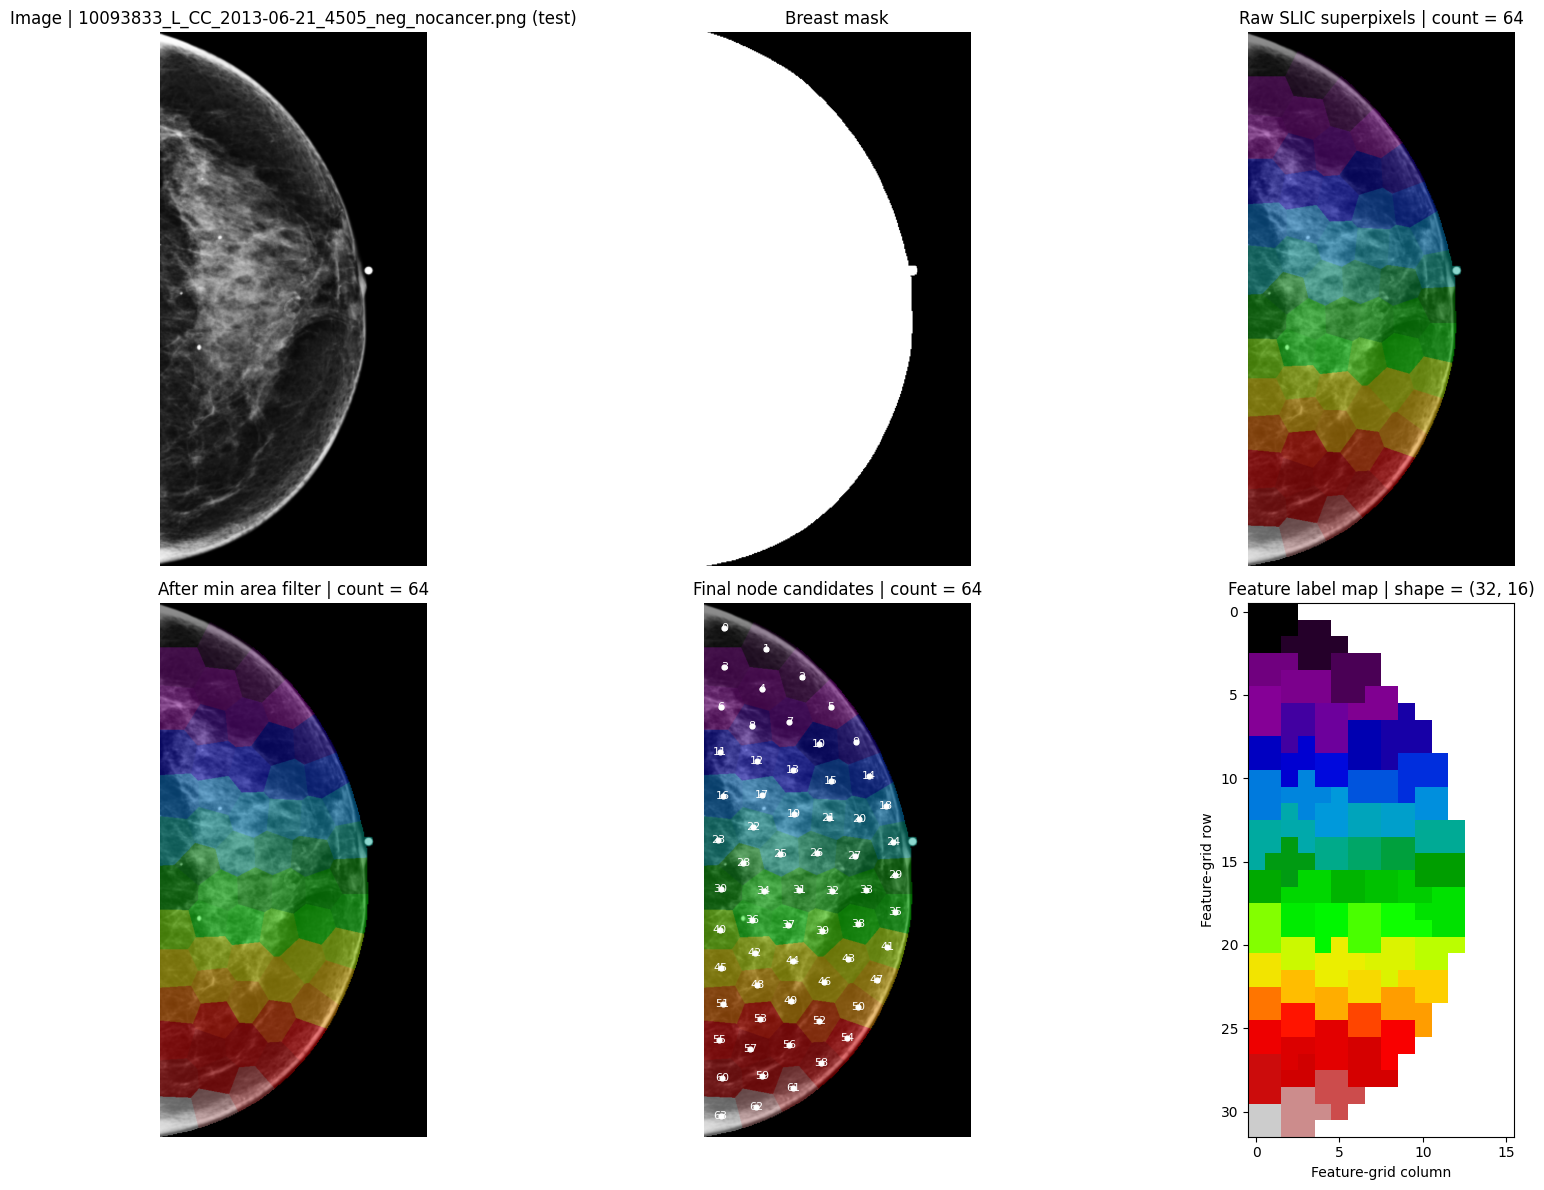

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

axes[0, 0].imshow(payload['image'], cmap='gray')
axes[0, 0].set_title(f"Image | {payload['summary']['image_id']} ({payload['summary']['split']})")
axes[0, 0].axis('off')

axes[0, 1].imshow(payload['breast_mask'], cmap='gray')
axes[0, 1].set_title('Breast mask')
axes[0, 1].axis('off')

plot_superpixel_overlay(
    axes[0, 2],
    payload['image'],
    payload['raw_label_map'],
    f"Raw SLIC superpixels | count = {payload['summary']['raw_slic_superpixels']}",
)

plot_superpixel_overlay(
    axes[1, 0],
    payload['image'],
    payload['filtered_label_map'],
    f"After min area filter | count = {payload['summary']['after_min_area_filter']}",
)

plot_superpixel_overlay(
    axes[1, 1],
    payload['image'],
    payload['final_label_map'],
    f"Final node candidates | count = {payload['summary']['final_node_candidates']}",
    show_ids=True,
    centroids_image=payload['node_centroids_image'],
)

plot_feature_grid(
    axes[1, 2],
    payload['feature_label_map'],
    f"Feature label map | shape = {payload['feature_label_map'].shape}",
)

plt.tight_layout()
plt.show()


## Thresholded Edges vs Final Graph

Left: only edges whose cosine similarity is at least `SIMILARITY_THRESHOLD`.

Right: the final graph after fallback neighbors and self-loops are added by `_build_similarity_adjacency(...)`.


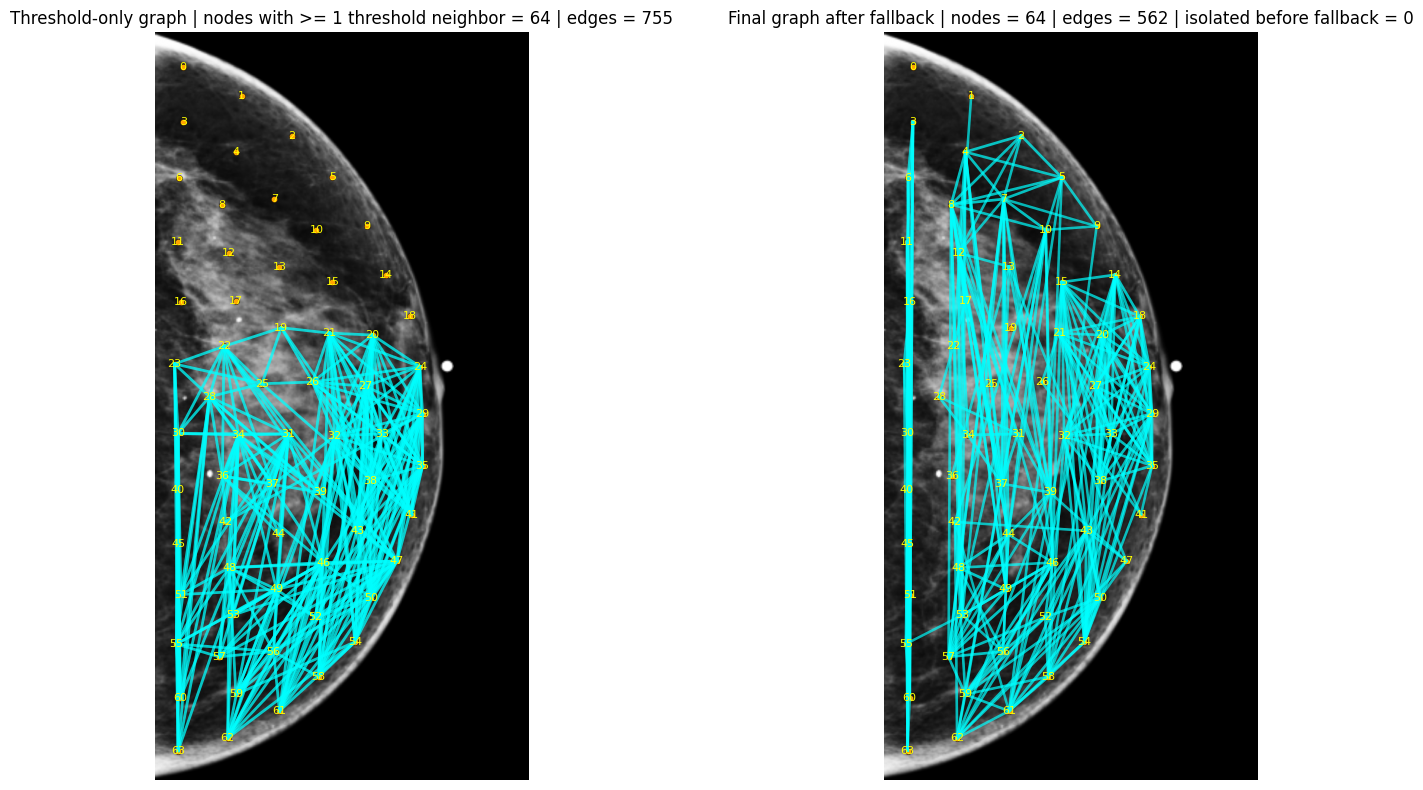

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

draw_graph_overlay(
    axes[0],
    payload['image'],
    payload['node_centroids_image'],
    payload['threshold_adj'],
    title=(
        'Threshold-only graph | '
        f"nodes with >= 1 threshold neighbor = {payload['summary']['nodes_with_threshold_neighbor']} | "
        f"edges = {payload['summary']['threshold_only_edges']}"
    ),
    max_edges=MAX_DRAWN_EDGES,
)

draw_graph_overlay(
    axes[1],
    payload['image'],
    payload['node_centroids_image'],
    payload['final_adjacency'],
    title=(
        'Final graph after fallback | '
        f"nodes = {payload['summary']['final_node_candidates']} | "
        f"edges = {payload['summary']['final_edges_after_fallback']} | "
        f"isolated before fallback = {payload['summary']['isolated_before_fallback']}"
    ),
    max_edges=MAX_DRAWN_EDGES,
)

plt.tight_layout()
plt.show()


## Similarity and Adjacency Matrices

These plots are useful when you want to inspect which nodes are strongly similar and how the final weighted adjacency differs from simple thresholding.


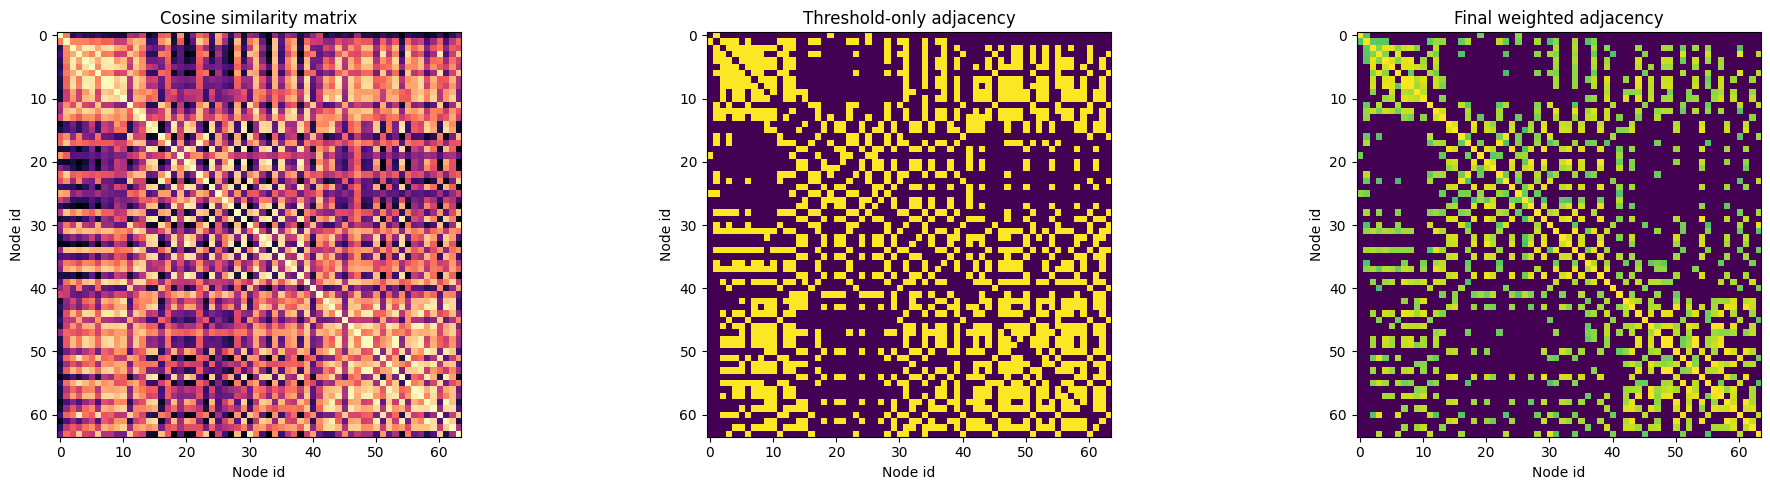

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sim = payload['threshold_similarity'].clone()
if sim.numel() > 0:
    sim.fill_diagonal_(1.0)

axes[0].imshow(sim.numpy(), cmap='magma')
axes[0].set_title('Cosine similarity matrix')
axes[0].set_xlabel('Node id')
axes[0].set_ylabel('Node id')

axes[1].imshow(payload['threshold_adj'].numpy(), cmap='viridis')
axes[1].set_title('Threshold-only adjacency')
axes[1].set_xlabel('Node id')
axes[1].set_ylabel('Node id')

axes[2].imshow(payload['final_adjacency'].numpy(), cmap='viridis')
axes[2].set_title('Final weighted adjacency')
axes[2].set_xlabel('Node id')
axes[2].set_ylabel('Node id')

plt.tight_layout()
plt.show()


## Feature Diagnostics

The tables and plots below show the feature-map size, node-feature matrix size, a node-by-channel heatmap, and the selected node's pooling mask plus feature vector.


Image path: /mnt/cv_data/users/mengxu/EMBED_Split_Cropped_PNG_Uniform_Orientation/test/10093833_L_CC_2013-06-21_4505_neg_nocancer.png
Feature map shape: (512, 32, 16)
Node feature matrix shape: (64, 512)
Pooling matrix shape: (64, 512)
Selected node id: 0


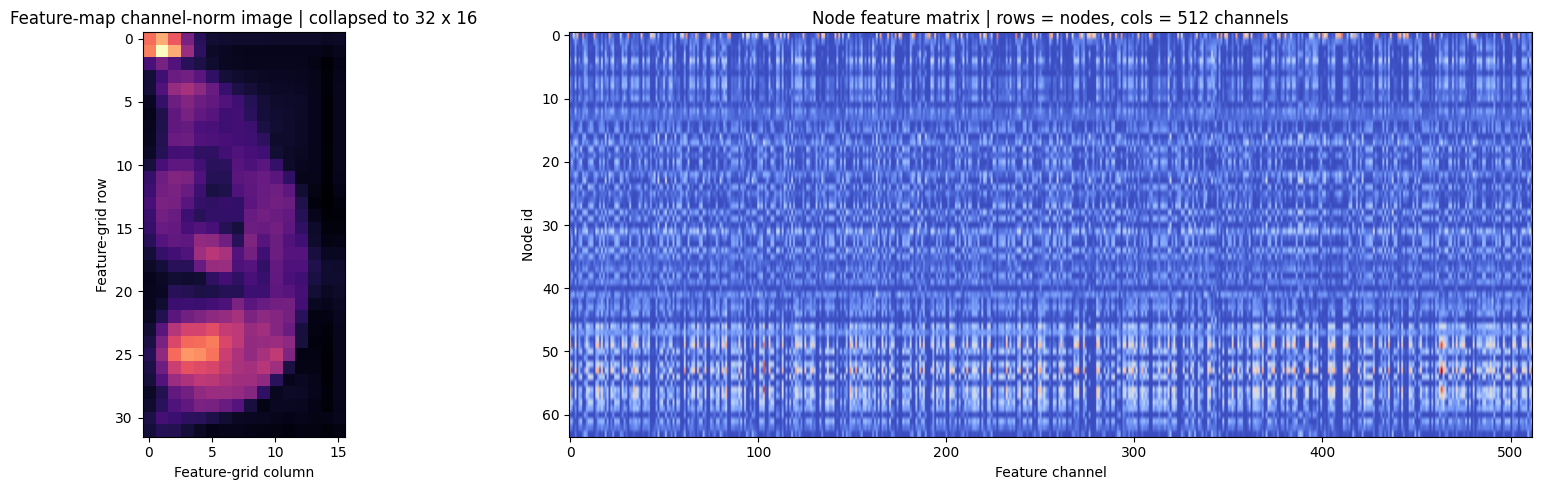

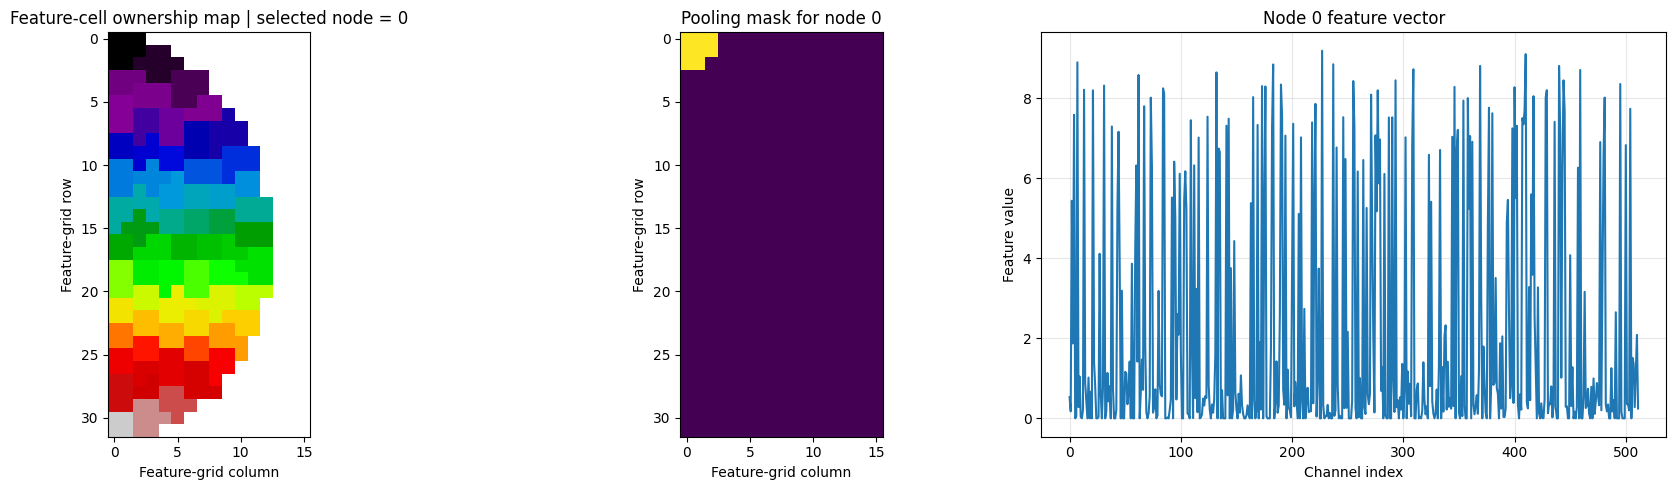

In [16]:
print('Image path:', payload['image_path'])
print('Feature map shape:', tuple(payload['feature_map'].shape))
print('Node feature matrix shape:', tuple(payload['node_features'].shape))
print('Pooling matrix shape:', tuple(payload['pooling_matrix'].shape))
print('Selected node id:', payload['selected_node_id'])

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

feature_map_magnitude = payload['feature_map'].norm(dim=0).numpy()
axes[0].imshow(feature_map_magnitude, cmap='magma', interpolation='nearest')
axes[0].set_title('Feature-map channel-norm image | collapsed to 32 x 16')
axes[0].set_xlabel('Feature-grid column')
axes[0].set_ylabel('Feature-grid row')

axes[1].imshow(payload['node_features'].numpy(), aspect='auto', cmap='coolwarm')
axes[1].set_title('Node feature matrix | rows = nodes, cols = 512 channels')
axes[1].set_xlabel('Feature channel')
axes[1].set_ylabel('Node id')

plt.tight_layout()
plt.show()

show_node_feature_diagnostics(payload, payload['selected_node_id'])


## Optional: Compare with Cached Metadata

If the precomputed `.superpixel_graph.pt` file exists, this cell compares a few key shapes and counts against the notebook reconstruction.


In [ ]:
if payload['cached_metadata'] is None:
    print('No cached metadata file found for this image.')
else:
    cached = payload['cached_metadata']
    compare = pd.DataFrame(
        {
            'reconstructed': {
                'num_nodes': payload['summary']['final_node_candidates'],
                'feature_map_shape': tuple(payload['feature_map'].shape),
                'feature_label_map_shape': tuple(payload['feature_label_map'].shape),
                'pooling_matrix_shape': tuple(payload['pooling_matrix'].shape),
            },
            'cached_file': {
                'num_nodes': int(cached['num_nodes']),
                'feature_map_shape': tuple(cached['feature_map_shape']),
                'feature_label_map_shape': tuple(cached['feature_label_map'].shape),
                'pooling_matrix_shape': tuple(cached['pooling_matrix'].shape),
            },
        }
    )
    compare
